# Premier League Dataset with pandas

We have cleaned this data and uploaded it to GitHub, now we will use pandas to download it to our file here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Getting the url code

In [2]:
url = 'https://raw.githubusercontent.com/kkathait/D501_Final_Project/refs/heads/main/combined_data.csv'

df_premier = pd.read_csv(url)

# Converting our data.

Our data does not contain a standard Win - Loss - Tie record for our team, so I created one

In [17]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_wins = (home_games["FTR"] == "H").sum()
    home_losses = (home_games["FTR"] == "A").sum()
    home_draws = (home_games["FTR"] == "D").sum()
    
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_wins = (away_games["FTR"] == "A").sum()
    away_losses = (away_games["FTR"] == "H").sum()
    away_draws = (away_games["FTR"] == "D").sum()
    
    records.append({
        "Team": team,
        "Wins": home_wins + away_wins,
        "Losses": home_losses + away_losses,
        "Draws": home_draws + away_draws,
        "Games": home_wins + away_wins + home_losses + away_losses + home_draws + away_draws
    })

standings = pd.DataFrame(records)

standings = standings.sort_values("Games", ascending = False)

standings

,Team,Wins,Losses,Draws,Games
0,Arsenal,154,56,56,266
1,Aston Villa,114,99,53,266
6,Chelsea,123,77,66,266
4,Brighton,90,89,87,266
7,Crystal Palace,82,103,81,266
8,Everton,86,110,70,266
26,West Ham,91,114,61,266
27,Wolves,81,124,61,266
16,Man United,127,74,65,266
17,Newcastle,107,96,63,266


# Data Visualization
Let us look at how the data looks with some graphs

# Team Records

First we want to make a stacked bar graph and a grouped bar graph to show team records

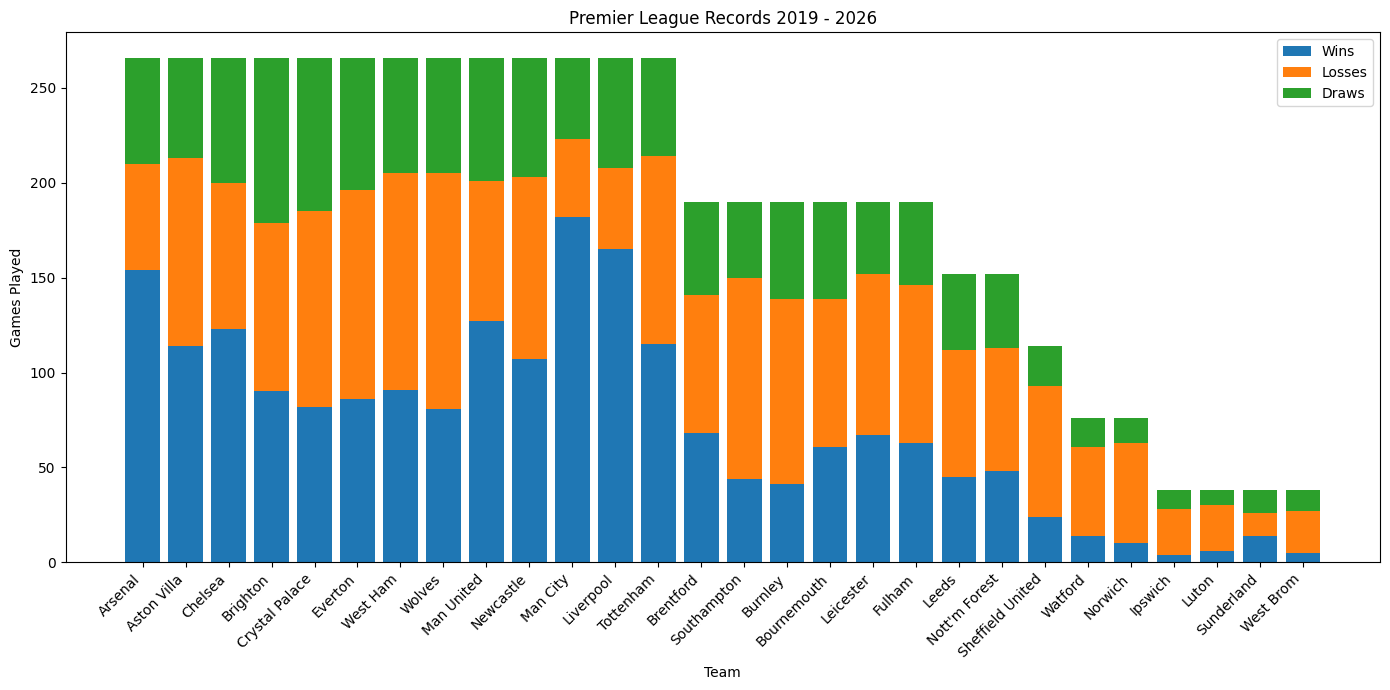

In [22]:
x = np.arange(len(standings["Games"]))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(
    standings["Team"],
    standings["Wins"],
    label="Wins"
)

plt.bar(
    standings["Team"],
    standings["Losses"],
    bottom=standings["Wins"],
    label="Losses"
)

plt.bar(
    standings["Team"],
    standings["Draws"],
    bottom=standings["Wins"] + standings["Losses"],
    label="Draws"
)
plt.xlabel("Team")
plt.ylabel("Games Played")
plt.title("Premier League Records 2019 - 2026")
plt.xticks(x, standings["Team"], rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

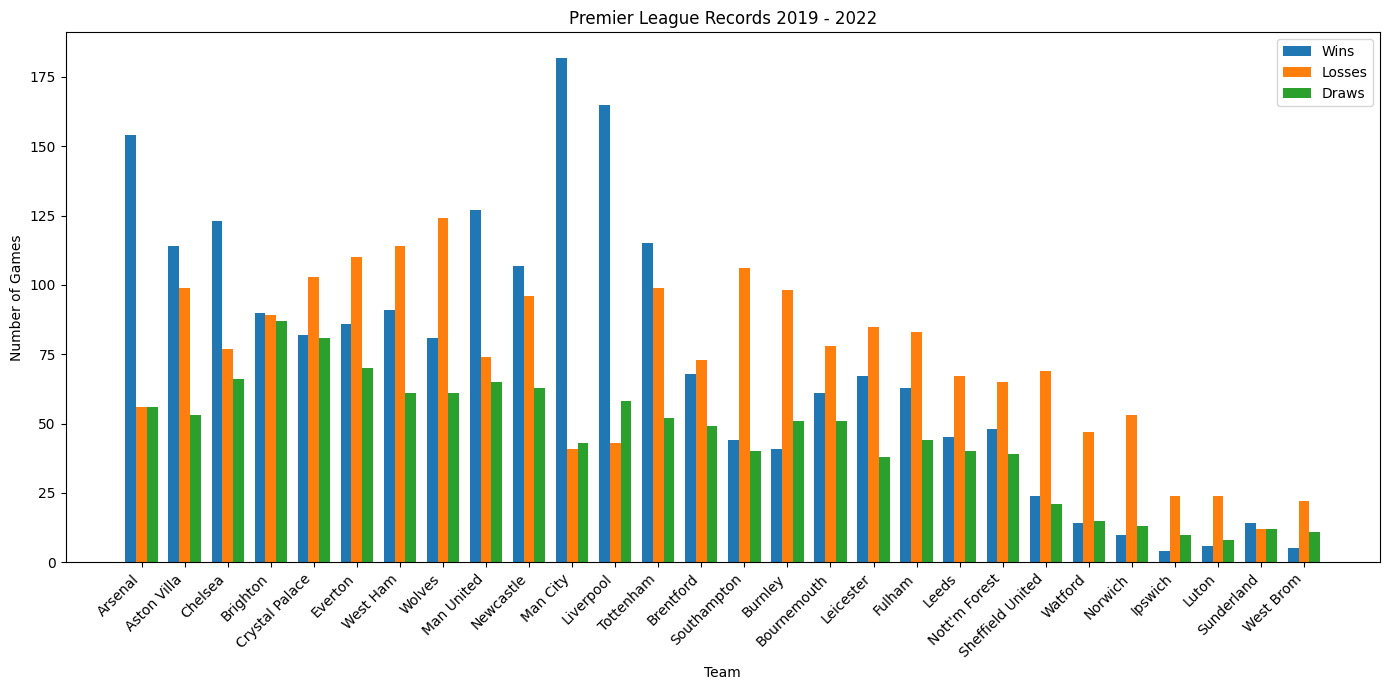

In [21]:
x = np.arange(len(standings["Team"]))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(x - width, standings["Wins"], width, label="Wins")
plt.bar(x, standings["Losses"], width, label="Losses")
plt.bar(x + width, standings["Draws"], width, label="Draws")

plt.xlabel("Team")
plt.ylabel("Number of Games")
plt.title("Premier League Records 2019 - 2022")
plt.xticks(x, standings["Team"], rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

# Goals

In [7]:
for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_for = home_games["FTHG"].sum()
    home_goals_against = home_games["FTAG"].sum()
    
    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_for = away_games["FTAG"].sum()
    away_goals_against = away_games["FTHG"].sum()
    
    records.append({
        "Team": team,
        "Goals For": home_goals_for + away_goals_for,
        "Goals Against": home_goals_against + away_goals_against
    })

goals_table = pd.DataFrame(records)

goals_table["Goal Difference"] = (
    goals_table["Goals For"] - goals_table["Goals Against"]
)

goals_table = goals_table.sort_values(
    "Goal Difference",
    ascending=False
)

goals_table

,Team,Wins,Losses,Draws,Goals For,Goals Against,Goal Difference
43,Man City,NaN,NaN,NaN,623.0,239.0,384.0
41,Liverpool,NaN,NaN,NaN,557.0,283.0,274.0
28,Arsenal,NaN,NaN,NaN,491.0,268.0,223.0
34,Chelsea,NaN,NaN,NaN,440.0,328.0,112.0
44,Man United,NaN,NaN,NaN,424.0,342.0,82.0
51,Tottenham,NaN,NaN,NaN,454.0,378.0,76.0
45,Newcastle,NaN,NaN,NaN,402.0,379.0,23.0
29,Aston Villa,NaN,NaN,NaN,389.0,374.0,15.0
31,Brentford,NaN,NaN,NaN,283.0,276.0,7.0
32,Brighton,NaN,NaN,NaN,366.0,364.0,2.0


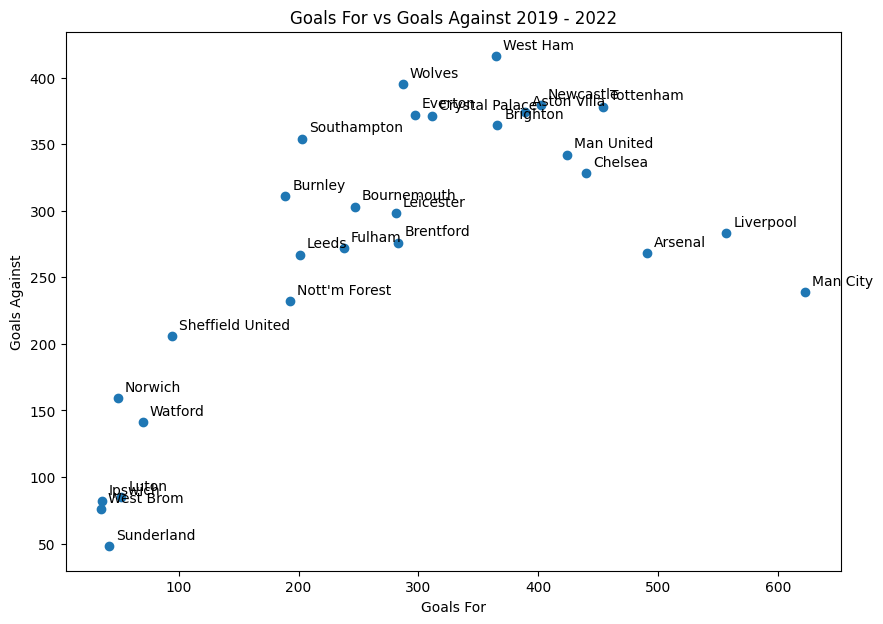

In [8]:
plt.figure(figsize=(10, 7))

plt.scatter(
    goals_table["Goals For"],
    goals_table["Goals Against"]
)

for _, row in goals_table.iterrows():
    plt.annotate(
        row["Team"],
        (row["Goals For"], row["Goals Against"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Goals For")
plt.ylabel("Goals Against")
plt.title("Goals For vs Goals Against 2019 - 2022")

plt.show()

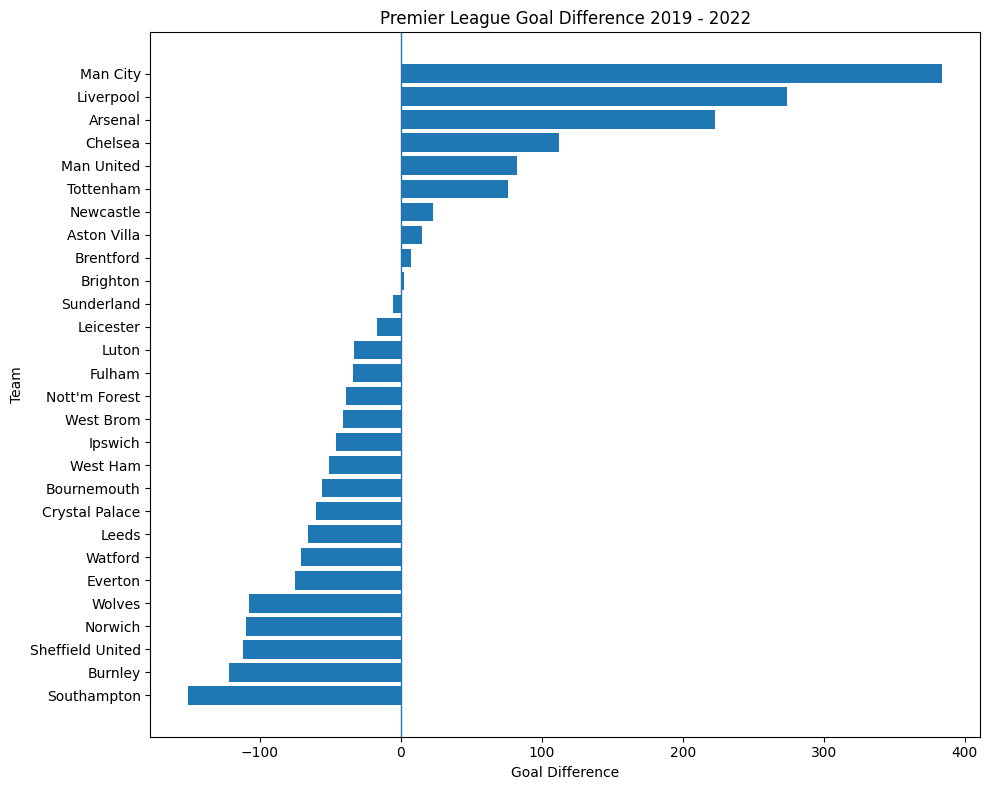

In [9]:
goals_table = goals_table.sort_values("Goal Difference")

plt.figure(figsize=(10, 8))

plt.barh(
    goals_table["Team"],
    goals_table["Goal Difference"]
)

plt.xlabel("Goal Difference")
plt.ylabel("Team")
plt.title("Premier League Goal Difference 2019 - 2022")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()